# Lab 1 — Intro to NumPy, Linear Regression, and Gradient Descent on a Real Biological Data Matrix

Author: Dario Righelli

This notebook is designed for a Master's degree course.

The goal of this lab is to introduce the computational foundations behind supervised learning, starting from a **real single-cell RNA sequencing dataset** and arriving at the implementation of **linear regression trained with Gradient Descent**.

We will use **NumPy** for the core computations, **pandas** to import the dataset, and **Matplotlib** for visualization.

## Learning goals

By the end of this notebook, you should be able to:

- import a tabular biological dataset in Python
- represent a biological dataset as a NumPy matrix
- understand the difference between matrix orientation in bioinformatics and machine learning
- perform basic NumPy operations on biological data
- define a linear regression model
- compute predictions, residuals, and the Mean Squared Error
- understand the role of the gradient in optimization
- implement Gradient Descent step by step
- evaluate the model visually and numerically

## Important note on matrix orientation

In bioinformatics, count or expression matrices are often stored with:

- **rows = features**
- **columns = cells or samples**

In machine learning, instead, we usually want:

- **rows = samples**
- **columns = features**

Therefore, in this lab we will work with a matrix where:

- each **row** is one cell
- each **column** is one cell-level feature

This means that, compared with many standard bioinformatics matrices, the data matrix used for machine learning is often effectively **transposed**.

## Dataset used in this lab

We will use a real single-cell RNA sequencing (single-cell RNA-seq) dataset exported from Bioconductor.

The input file is:

- `zeisel_ml_regression.csv`

It should be in the same directory as this notebook.

Each row represents one cell, and the columns correspond to real cell-level Quality Control (QC) features computed from a single-cell RNA sequencing (single-cell RNA-seq) dataset:

- `log10_total_counts`
- `pct_mito`

The target is a continuous variable representing the log-transformed number of detected genes per cell:

- `log10_n_genes`

## Structure of the notebook

1. Setup
2. A real biological data matrix in NumPy
3. Basic NumPy operations on biological data
4. Supervised learning notation on a biological matrix
5. Linear regression model
6. Residuals and Mean Squared Error
7. Cost function as a function of the parameters
8. The gradient
9. Gradient Descent update
10. Full training loop
11. Model evaluation for regression
12. Effect of the learning rate
13. Biological interpretation
14. Final recap


In [1]:
# Section 0 - Setup
# We import the libraries used throughout the notebook.
# pandas is used to import the CSV file.
# NumPy is used for numerical computation.
# Matplotlib is used for simple plots.
# The random seed makes the notebook reproducible.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)


## Section 1 — A real biological data matrix in NumPy

We start from a real single-cell RNA sequencing (single-cell RNA-seq) dataset prepared in Bioconductor and exported as a comma-separated values (CSV) file.

The file used in this notebook is:

- `zeisel_ml_regression.csv`

It contains one row per cell and three key columns:

- `log10_total_counts`: log-transformed total number of counts detected in the cell
- `pct_mito`: percentage of mitochondrial counts
- `log10_n_genes`: log-transformed number of detected genes

In this lab, we will use:

- `log10_total_counts` and `pct_mito` as input features
- `log10_n_genes` as the continuous target

This gives us a real biological regression problem.

The goal is to use cell-level Quality Control (QC) features to predict the number of detected genes per cell.


In [2]:
# Section 1 - Load a real biological data matrix
# The CSV file should be in the same directory as this notebook.
# If it is somewhere else, change the path below.

data_path = Path("zeisel_ml_regression.csv")

if not data_path.exists():
    raise FileNotFoundError(
        "Could not find 'zeisel_ml_regression.csv' in the current directory. "
        "Please copy the file next to this notebook or update data_path."
    )

qc_data = pd.read_csv(data_path)

print("First 5 rows of the imported table:")
display(qc_data.head())

required_columns = ["cell_id", "log10_total_counts", "pct_mito", "log10_n_genes"]
missing_columns = [col for col in required_columns if col not in qc_data.columns]

if len(missing_columns) > 0:
    raise ValueError(f"Missing required columns: {missing_columns}")

feature_names = ["log10_total_counts", "pct_mito"]
target_name = "log10_n_genes"

# X_bio is the raw machine learning matrix before standardization.
# Rows are cells and columns are features.
X_bio = qc_data[feature_names].to_numpy()
y_bio = qc_data[target_name].to_numpy()

print("\nShape of X_bio:", X_bio.shape)
print("Shape of y_bio:", y_bio.shape)

print("\nFirst 5 rows of the biological data matrix:")
print(X_bio[:5])

print("\nFirst 5 target values:")
print(y_bio[:5])


First 5 rows of the imported table:


,cell_id,log10_total_counts,pct_mito,log10_n_genes
0,1772071015_C02,4.349375,3.462468,3.687707
1,1772071017_G12,4.359266,4.901832,3.673297
2,1772071017_A05,4.513151,2.920783,3.782186
3,1772071014_B06,4.525382,1.822521,3.767379
4,1772067065_H06,4.336360,0.755969,3.674402



Shape of X_bio: (3005, 2)
Shape of y_bio: (3005,)

First 5 rows of the biological data matrix:
[[4.34937467 3.46246757]
 [4.35926616 4.90183217]
 [4.51315099 2.92078297]
 [4.52538174 1.82252051]
 [4.33635965 0.75596939]]

First 5 target values:
[3.68770728 3.67329744 3.78218587 3.76737852 3.67440181]


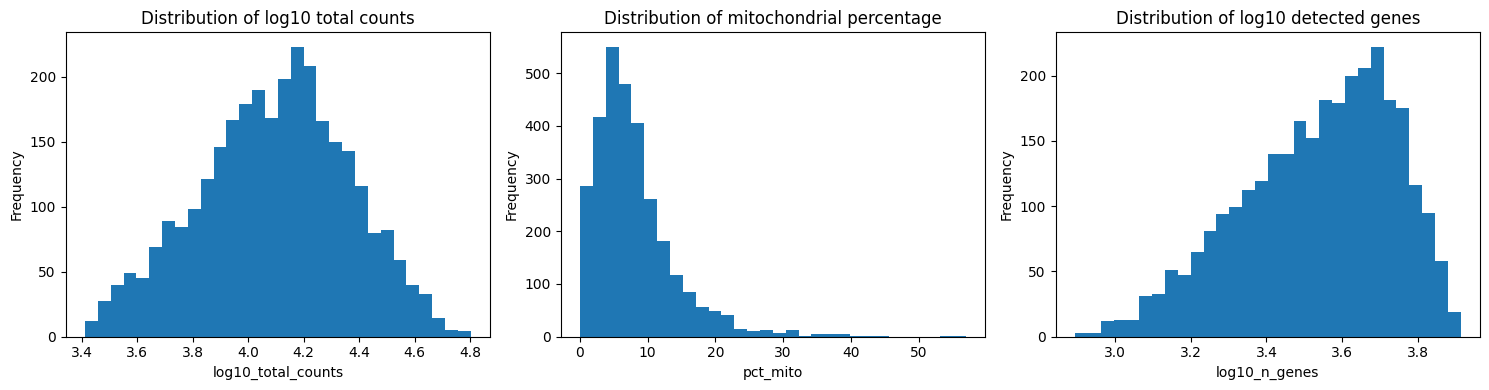

In [3]:
# Section 1 - Visual summary of the biological matrix and target

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(qc_data["log10_total_counts"], bins=30)
axes[0].set_title("Distribution of log10 total counts")
axes[0].set_xlabel("log10_total_counts")
axes[0].set_ylabel("Frequency")

axes[1].hist(qc_data["pct_mito"], bins=30)
axes[1].set_title("Distribution of mitochondrial percentage")
axes[1].set_xlabel("pct_mito")
axes[1].set_ylabel("Frequency")

axes[2].hist(qc_data["log10_n_genes"], bins=30)
axes[2].set_title("Distribution of log10 detected genes")
axes[2].set_xlabel("log10_n_genes")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


The three distributions show that the variables have different shapes and scales.  
`log10_total_counts` and `log10_n_genes` are relatively concentrated after log transformation, while `pct_mito` is more right-skewed, with a small number of cells showing higher mitochondrial percentage.

This is a first reason why scaling and visual inspection are useful before fitting a model.


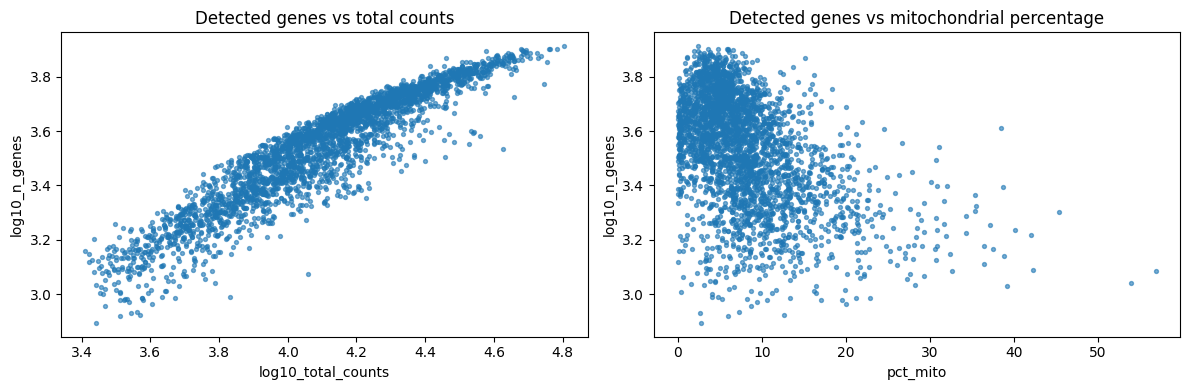

In [4]:
# Section 1 - Visual inspection of relationships with the target

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(
    qc_data["log10_total_counts"],
    qc_data["log10_n_genes"],
    s=8,
    alpha=0.6
)
axes[0].set_title("Detected genes vs total counts")
axes[0].set_xlabel("log10_total_counts")
axes[0].set_ylabel("log10_n_genes")

axes[1].scatter(
    qc_data["pct_mito"],
    qc_data["log10_n_genes"],
    s=8,
    alpha=0.6
)
axes[1].set_title("Detected genes vs mitochondrial percentage")
axes[1].set_xlabel("pct_mito")
axes[1].set_ylabel("log10_n_genes")

plt.tight_layout()
plt.show()


`log10_total_counts` shows a clear positive relationship with `log10_n_genes`: cells with more total counts tend to have more detected genes.

The relationship between `pct_mito` and `log10_n_genes` is weaker and more scattered.  
There are some cells with high mitochondrial percentage, but the trend is less direct than for total counts.


### Exercises for Section 1

**Exercise 1.1**  
Print:
- the shape of `X_bio`
- the number of rows
- the number of columns

**Exercise 1.2**  
Answer in words:
- what does one row represent in this dataset?
- what does one column represent?

**Exercise 1.3**  
Extract the first row and the first column of `X_bio`.

**Exercise 1.4**  
Print the first 5 values of the target `y_bio`.


In [5]:
# Exercises for Section 1

# Write your code below.


## Section 2 — Basic NumPy operations on biological data

Now that we have a real biological data matrix, we can use it to practice basic NumPy operations.

This section covers:

- indexing
- slicing
- column extraction
- summary statistics
- standardization

All operations are performed on the machine learning matrix `X_bio`, where rows are cells and columns are Quality Control (QC) features.


In [6]:
# Section 2 - Indexing and slicing on biological data

print("First row of X_bio:")
print(X_bio[0])

print("\nSecond row of X_bio:")
print(X_bio[1])

print("\nFirst column of X_bio (log10_total_counts):")
print(X_bio[:, 0][:5])

print("\nSecond column of X_bio (pct_mito):")
print(X_bio[:, 1][:5])

print("\nLast three rows:")
print(X_bio[-3:, :])

print("\nAll rows, first column only:")
#print(X_bio[:, 0])
# not printing all rows to avoid flooding the output, but you can uncomment the line above to see them all.

First row of X_bio:
[4.34937467 3.46246757]

Second row of X_bio:
[4.35926616 4.90183217]

First column of X_bio (log10_total_counts):
[4.34937467 4.35926616 4.51315099 4.52538174 4.33635965]

Second column of X_bio (pct_mito):
[3.46246757 4.90183217 2.92078297 1.82252051 0.75596939]

Last three rows:
[[ 3.69844854 19.58742239]
 [ 3.49136169  6.55050016]
 [ 3.81524559 31.74165901]]

All rows, first column only:


In [7]:
# Section 2 - Summary statistics

feature_means = np.mean(X_bio, axis=0)
feature_stds = np.std(X_bio, axis=0)

print("Feature means:")
for name, value in zip(feature_names, feature_means):
    print(f"{name}: {value:.3f}")

print("\nFeature standard deviations:")
for name, value in zip(feature_names, feature_stds):
    print(f"{name}: {value:.3f}")


Feature means:
log10_total_counts: 4.095
pct_mito: 7.956

Feature standard deviations:
log10_total_counts: 0.269
pct_mito: 6.062


In [8]:
# Section 2 - Standardization

X_bio_std = (X_bio - np.mean(X_bio, axis=0)) / np.std(X_bio, axis=0)

print("First 5 rows of the standardized matrix:")
print(X_bio_std[:5])


First 5 rows of the standardized matrix:
[[ 0.94567039 -0.74123002]
 [ 0.98243324 -0.50379949]
 [ 1.55436365 -0.83058365]
 [ 1.59982064 -1.01174764]
 [ 0.8972986  -1.18768069]]


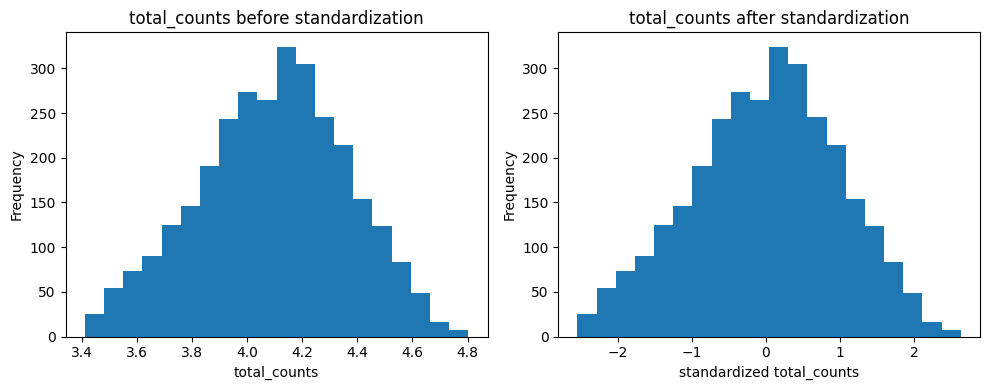

In [9]:
# Section 2 - Visualize one feature before and after standardization

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(X_bio[:, 0], bins=20)
axes[0].set_title("total_counts before standardization")
axes[0].set_xlabel("total_counts")
axes[0].set_ylabel("Frequency")

axes[1].hist(X_bio_std[:, 0], bins=20)
axes[1].set_title("total_counts after standardization")
axes[1].set_xlabel("standardized total_counts")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


Standardization changes the scale of `log10_total_counts`, but not the overall shape of its distribution.  
After standardization, the feature is centered around zero and has unit variance, which is useful for Gradient Descent.


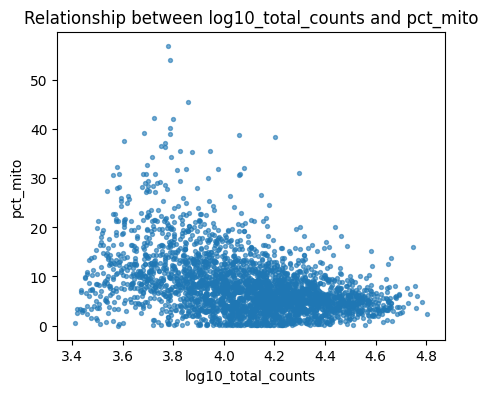

In [10]:
# Section 2 - Scatter plot between the two biological features

plt.figure(figsize=(5, 4))
plt.scatter(X_bio[:, 0], X_bio[:, 1], s=8, alpha=0.6)
plt.xlabel("log10_total_counts")
plt.ylabel("pct_mito")
plt.title("Relationship between log10_total_counts and pct_mito")
plt.show()


The scatter plot suggests that cells with higher `log10_total_counts` often have lower or moderate `pct_mito`, while high mitochondrial percentages are mostly concentrated among cells with lower total counts.

This pattern is biologically plausible, because high mitochondrial percentage is often associated with lower-quality cells.


### Exercises for Section 2

**Exercise 2.1**  
Compute:
- the mean of each column
- the standard deviation of each column

**Exercise 2.2**  
Extract only the `pct_mito` column.

**Exercise 2.3**  
Create a standardized version of `X_bio` and print its first 3 rows.


In [11]:
# Exercises for Section 2

# Write your code below.


## Section 3 — Supervised learning notation on a biological matrix

In supervised learning we usually work with:

- a matrix of inputs, usually called $X$
- a vector of targets, usually called $y$

In this notebook:

- $X$ is the standardized biological feature matrix
- $y$ is the vector containing the log-transformed number of detected genes per cell

So:

- each row of $X$ is one cell
- each column of $X$ is one Quality Control (QC) feature
- each entry of $y$ is the target value for one cell

We now rename our objects explicitly as `X` and `y`.


In [12]:
# Section 3 - Define X and y explicitly

X = X_bio_std
y = y_bio

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (3005, 2)
Shape of y: (3005,)


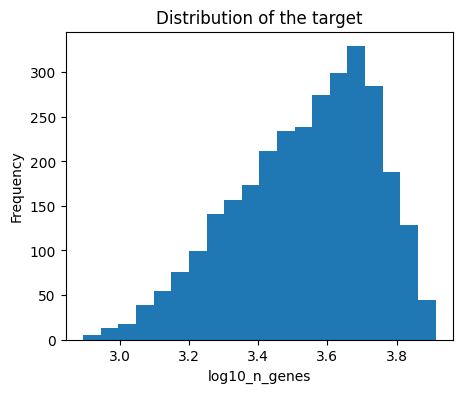

In [13]:
# Section 3 - Visualize the target

plt.figure(figsize=(5, 4))
plt.hist(y, bins=20)
plt.xlabel("log10_n_genes")
plt.ylabel("Frequency")
plt.title("Distribution of the target")
plt.show()


The target `log10_n_genes` is not uniformly distributed.  
Most cells have relatively high values, while fewer cells appear in the lower tail.

This helps us understand the range of values that the regression model will try to predict.


### Important note on loss and evaluation

In our case, for linear regression, we use the **Mean Squared Error (MSE)** both as the **loss function** and as the **basic evaluation criterion during training**.

That means:

- we minimize the Mean Squared Error during optimization
- we also inspect the Mean Squared Error to judge how well the model is fitting the training data


## Section 4 — Linear regression model

A linear regression model predicts the target as:

$$
\hat{y} = Xw + b
$$

where:

- $w$ is the vector of feature weights
- $b$ is the bias or intercept

The prediction for each cell is therefore a weighted combination of its features plus a constant shift.


In [14]:
# Section 4 - Linear prediction function

# Here we define a simple linear prediction function that takes the input matrix `X`, 
# a weight vector `w`, and a bias term `b`, 
# and computes the predicted values as a linear combination of the features plus the bias.
def predict(X, w, b):
    return X @ w + b

w_example = np.array([1.0, -1.0])
b_example = 0.0

y_pred_example = predict(X, w_example, b_example)

print("Example weights:", w_example)
print("Example bias:", b_example)
print("\nFirst 5 predictions:")
print(y_pred_example[:5])


Example weights: [ 1. -1.]
Example bias: 0.0

First 5 predictions:
[1.68690041 1.48623273 2.38494731 2.61156829 2.08497928]


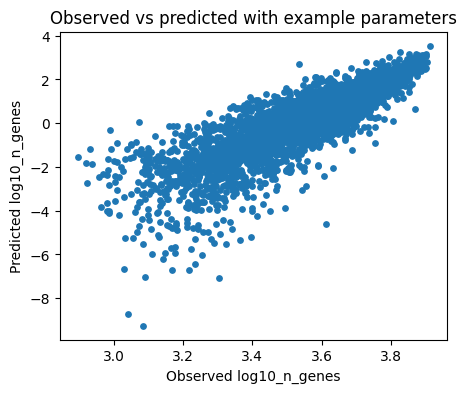

In [15]:
# Section 4 - Compare observed and predicted values for an example parameter vector

plt.figure(figsize=(5, 4))
plt.scatter(y, y_pred_example, s=15)
plt.xlabel("Observed log10_n_genes")
plt.ylabel("Predicted log10_n_genes")
plt.title("Observed vs predicted with example parameters")
plt.show()


These predictions come from arbitrary example parameters, not from a trained model.  
The observed-vs-predicted plot already shows some positive association, but the scale and centering are not yet correct.

This motivates fitting the parameters instead of choosing them manually.


### Exercises for Section 4

**Exercise 4.1**  
Using:
- `w = np.array([1.0, -1.0])`
- `b = 0.0`

compute the predictions for `X`.

**Exercise 4.2**  
Change only one component of `w` and observe how the predictions change.

**Exercise 4.3**  
Change only `b` and observe how the predictions change.


In [16]:
# Exercises for Section 4

# Write your code below.


## Section 5 — Residuals and Mean Squared Error

The residuals are the differences between the predictions and the true values:

$$
r_i = \hat{y}_i - y_i
$$

A standard loss function for regression is the **Mean Squared Error**:

$$
\mathrm{MSE} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2
$$

In this lab, the Mean Squared Error has a double role:

- it is the function we minimize during training
- it is also the basic criterion we use to evaluate how well the model fits the training data


In [17]:
# Section 5 - Residuals and Mean Squared Error

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

residuals_example = y_pred_example - y
mse_example = mse(y, y_pred_example)

print("First 5 residuals:")
print(residuals_example[:5])

print("\nMean Squared Error:")
print(mse_example)


First 5 residuals:
[-2.00080687 -2.18706471 -1.39723856 -1.15581024 -1.58942253]

Mean Squared Error:
14.763367784966658


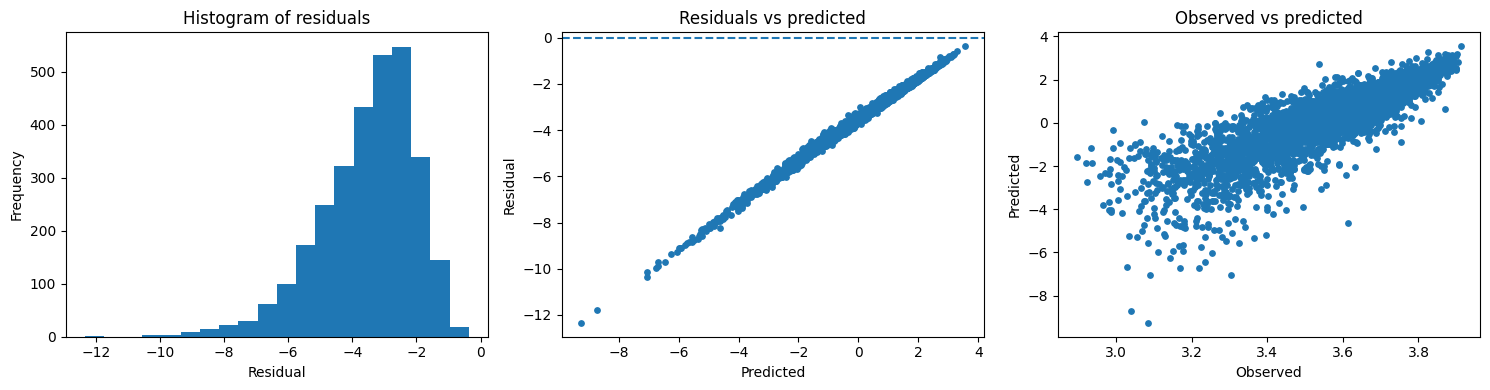

In [18]:
# Section 5 - Visualize residuals

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(residuals_example, bins=20)
axes[0].set_title("Histogram of residuals")
axes[0].set_xlabel("Residual")
axes[0].set_ylabel("Frequency")

axes[1].scatter(y_pred_example, residuals_example, s=15)
axes[1].axhline(0, linestyle="--")
axes[1].set_title("Residuals vs predicted")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual")

axes[2].scatter(y, y_pred_example, s=15)
axes[2].set_title("Observed vs predicted")
axes[2].set_xlabel("Observed")
axes[2].set_ylabel("Predicted")

plt.tight_layout()
plt.show()


With the example parameters, the residuals are not well centered around zero and the observed-vs-predicted relationship is imperfect.  
This is expected because the parameters have not been optimized yet.

The goal of training will be to reduce these residuals and lower the Mean Squared Error.


### Exercises for Section 5

**Exercise 5.1**  
Compute:
- predictions
- residuals
- Mean Squared Error

for the current values of `w_example` and `b_example`.

**Exercise 5.2**  
Compare two different sets of parameters and decide which one is better according to the Mean Squared Error.

**Exercise 5.3**  
Why do we square the residuals in the Mean Squared Error?


In [19]:
# Exercises for Section 5

# Write your code below.


## Section 6 — Cost function as a function of the parameters

The Mean Squared Error is also a function of the model parameters.

Different values of the parameters correspond to different models, and therefore to different values of the Mean Squared Error.

To build some intuition, we now simplify the problem and use only one standardized feature:

- `pct_mito`

This lets us visualize the cost as a function of a single weight.


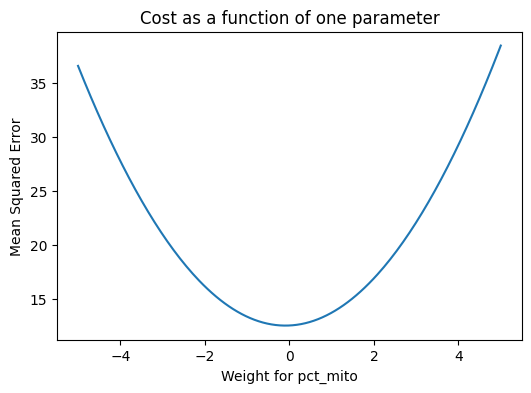

In [20]:
# Section 6 - Simplified one-feature problem

x_simple = X[:, 1]   # standardized pct_mito
y_simple = y

def predict_simple(x, w, b):
    return w * x + b

b_fixed = 0.0
weight_grid = np.linspace(-5, 5, 200)
cost_values = []

for w_val in weight_grid:
    y_hat = predict_simple(x_simple, w_val, b_fixed)
    cost_values.append(mse(y_simple, y_hat))

cost_values = np.array(cost_values)

plt.figure(figsize=(6, 4))
plt.plot(weight_grid, cost_values)
plt.xlabel("Weight for pct_mito")
plt.ylabel("Mean Squared Error")
plt.title("Cost as a function of one parameter")
plt.show()



The cost curve is approximately U-shaped.  
This means that very negative and very positive weights both lead to larger errors, while an intermediate value gives a lower Mean Squared Error.

This plot makes the idea of minimizing a loss function concrete.


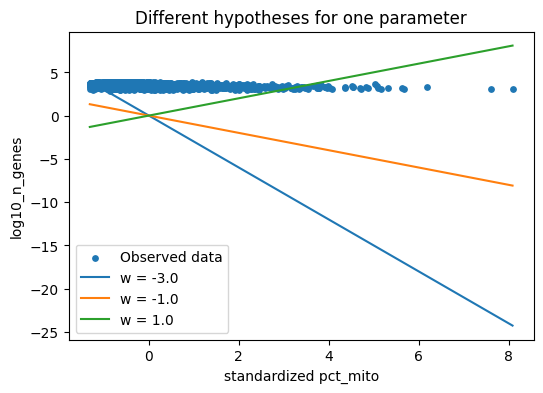

In [21]:
# Section 6 - Visualize different hypotheses for one parameter

sample_idx = np.argsort(x_simple)
x_sorted = x_simple[sample_idx]
y_sorted = y_simple[sample_idx]

plt.figure(figsize=(6, 4))
plt.scatter(x_simple, y_simple, s=15, label="Observed data")

for w_val in [-3.0, -1.0, 1.0]:
    y_line = predict_simple(x_sorted, w_val, b_fixed)
    plt.plot(x_sorted, y_line, label=f"w = {w_val}")

plt.xlabel("standardized pct_mito")
plt.ylabel("log10_n_genes")
plt.title("Different hypotheses for one parameter")
plt.legend()
plt.show()



Each line corresponds to a different value of the weight for `pct_mito`.  
Most of these simple one-feature hypotheses are not sufficient to explain the target well, which is why the full model will use both features.

The plot also shows that the choice of parameter directly changes the fitted relationship.


### Exercises for Section 6

**Exercise 6.1**  
Using only `pct_mito` as input, compute the Mean Squared Error for three different values of the weight.

**Exercise 6.2**  
Looking at the cost curve, identify approximately where the Mean Squared Error seems smaller.

**Exercise 6.3**  
Explain why different parameter values correspond to different hypotheses.


In [22]:
# Exercises for Section 6

# Write your code below.


## Section 7 — The gradient

The gradient tells us the direction of steepest increase of a function.

For optimization, this is very useful:

- the gradient points in the direction in which the loss increases the fastest
- the negative gradient points in the direction in which the loss decreases the fastest

For linear regression with Mean Squared Error, the gradients are:

$$
\frac{\partial L}{\partial w} = \frac{2}{n} X^T (Xw + b - y)
$$

$$
\frac{\partial L}{\partial b} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)
$$


In [23]:
# Section 7 - Compute the gradient for linear regression
# Here we implement the formulas for the gradients of the Mean Squared Error with respect to the 
# weights and bias in linear regression.
def compute_gradients(X, y, w, b):
    n = X.shape[0]
    y_pred = X @ w + b
    error = y_pred - y

    dw = (2 / n) * (X.T @ error)
    db = (2 / n) * np.sum(error)

    return dw, db

w0 = np.zeros(X.shape[1])
b0 = 0.0

dw0, db0 = compute_gradients(X, y, w0, b0)

print("Gradient with respect to w:")
print(dw0)

print("\nGradient with respect to b:")
print(db0)


Gradient with respect to w:
[-0.37445858  0.18816008]

Gradient with respect to b:
-7.0691187734885395


### Exercises for Section 7

**Exercise 7.1**  
Compute `dw` and `db` starting from:
- zero weights
- zero bias

**Exercise 7.2**  
Check the shape of `dw`.

**Exercise 7.3**  
Why must `dw` have the same shape as `w`?


In [24]:
# Exercises for Section 7

# Write your code below.


## Section 8 — Gradient Descent update

Gradient Descent updates the parameters by moving them in the direction of the negative gradient.

The update rule is:

$$
w \leftarrow w - \eta \nabla_w L
$$

$$
b \leftarrow b - \eta \frac{\partial L}{\partial b}
$$

where $\eta > 0$ is the learning rate.


In [25]:
# Section 8 - One Gradient Descent update

learning_rate = 0.1

w_step = np.zeros(X.shape[1])
b_step = 0.0
# We compute the loss before the update
loss_before = mse(y, predict(X, w_step, b_step))
# then we compute the gradients
dw_step, db_step = compute_gradients(X, y, w_step, b_step)
# we perform the update 
w_step = w_step - learning_rate * dw_step
b_step = b_step - learning_rate * db_step
# we compute the loss after the update to see if it has decreased
loss_after = mse(y, predict(X, w_step, b_step))

print("Loss before update:", loss_before)
print("Loss after update:", loss_after)

print("\nUpdated weights:")
print(w_step)

print("\nUpdated bias:")
print(b_step)


Loss before update: 12.533582540382378
Loss after update: 8.020815122773364

Updated weights:
[ 0.03744586 -0.01881601]

Updated bias:
0.706911877348854


### Exercises for Section 8

**Exercise 8.1**  
Compute:
- the loss before the update
- the loss after the update

**Exercise 8.2**  
Repeat the update manually for 3 iterations.

**Exercise 8.3**  
What happens if the learning rate is too small? What happens if it is too large?


In [26]:
# Exercises for Section 8

# Write your code below.


## Section 9 — Full training loop

Now that we understand one update step, we can implement the full training loop.

At each step, we:

1. compute predictions
2. compute the Mean Squared Error
3. compute the gradients
4. update the parameters
5. store the loss value


In [27]:
# Section 9 - Full training loop for linear regression

def train_linear_regression(X, y, learning_rate=0.1, n_steps=100):
    w = np.zeros(X.shape[1])
    b = 0.0
    loss_history = []

    for step in range(n_steps):
        y_pred = predict(X, w, b)
        loss = mse(y, y_pred)
        loss_history.append(loss)

        dw, db = compute_gradients(X, y, w, b)

        w = w - learning_rate * dw
        b = b - learning_rate * db

    return w, b, loss_history

w_fit, b_fit, loss_history = train_linear_regression(
    X, y,
    learning_rate=0.1,
    n_steps=200
)

print("Estimated weights:")
print(w_fit)

print("\nEstimated bias:")
print(b_fit)

print("\nInitial loss:")
print(loss_history[0])

print("\nFinal loss:")
print(loss_history[-1])


Estimated weights:
[ 0.17787701 -0.02360482]

Estimated bias:
3.534559386744269

Initial loss:
12.533582540382378

Final loss:
0.00494795274941649


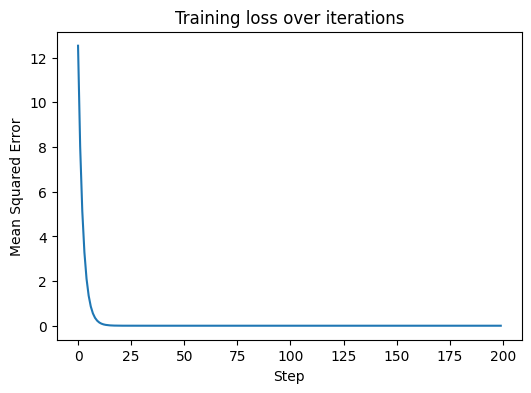

In [28]:
# Section 9 - Plot the training loss

plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Step")
plt.ylabel("Mean Squared Error")
plt.title("Training loss over iterations")
plt.show()


The training loss decreases rapidly during the first iterations and then reaches a plateau.  
This indicates that Gradient Descent is effectively reducing the Mean Squared Error and approaching a stable solution.


### Exercises for Section 9

**Exercise 9.1**  
Train the model with:
- `learning_rate = 0.1`
- `n_steps = 200`

**Exercise 9.2**  
Print:
- final weights
- final bias
- initial loss
- final loss

**Exercise 9.3**  
Does the loss decrease over time?


In [29]:
# Exercises for Section 9

# Write your code below.


## Section 10 — Model evaluation for regression

We now evaluate the fitted model using:

- the Mean Squared Error
- observed vs predicted values
- residuals
- residual distribution

Again, in this lab we use the Mean Squared Error both as the training loss and as the basic evaluation criterion during training.


In [30]:
# Section 10 - Evaluate the fitted model

y_pred_fit = predict(X, w_fit, b_fit)
residuals_fit = y_pred_fit - y
mse_fit = mse(y, y_pred_fit)
mae_fit = np.mean(np.abs(y - y_pred_fit))

print("Training Mean Squared Error:", mse_fit)
print("Training Mean Absolute Error:", mae_fit)


Training Mean Squared Error: 0.00494795274941649
Training Mean Absolute Error: 0.05419823844733398


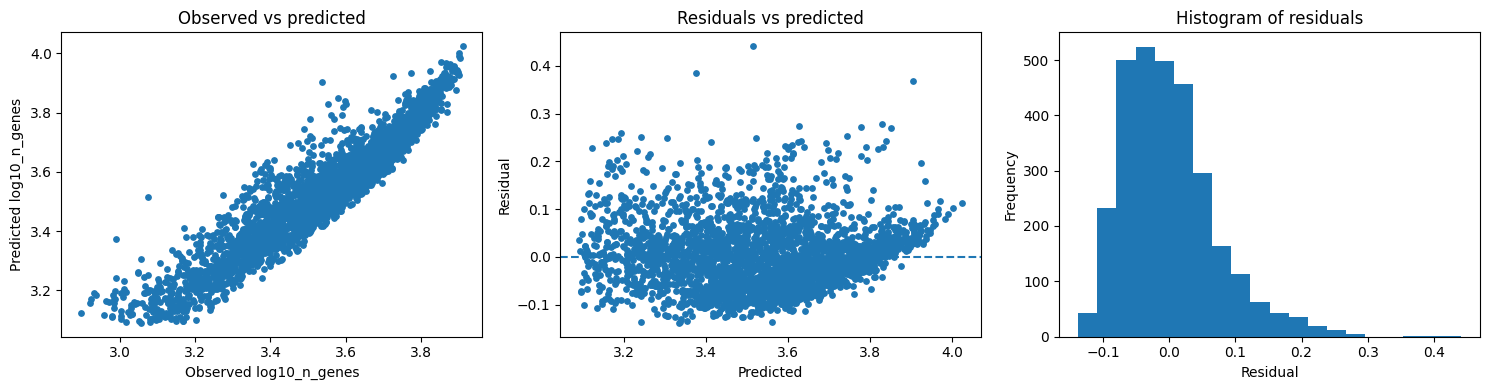

In [31]:
# Section 10 - Visual evaluation

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y, y_pred_fit, s=15)
axes[0].set_title("Observed vs predicted")
axes[0].set_xlabel("Observed log10_n_genes")
axes[0].set_ylabel("Predicted log10_n_genes")

axes[1].scatter(y_pred_fit, residuals_fit, s=15)
axes[1].axhline(0, linestyle="--")
axes[1].set_title("Residuals vs predicted")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual")

axes[2].hist(residuals_fit, bins=20)
axes[2].set_title("Histogram of residuals")
axes[2].set_xlabel("Residual")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()



After training, the observed-vs-predicted plot shows a strong positive relationship, indicating that the model captures much of the variation in `log10_n_genes`.

The residuals are more centered around zero, although their spread is not perfectly uniform.  
This suggests that the linear model is useful, but still simplified.


### Exercises for Section 10

**Exercise 10.1**  
Compute the training Mean Squared Error for the fitted model.

**Exercise 10.2**  
Create an observed vs predicted plot.

**Exercise 10.3**  
Look at the residual plot. Do the residuals seem centered around zero?


In [32]:
# Exercises for Section 10

# Write your code below.


## Section 11 — Effect of the learning rate

The learning rate is a key hyperparameter in Gradient Descent.

We now compare the optimization behavior for different values of the learning rate.


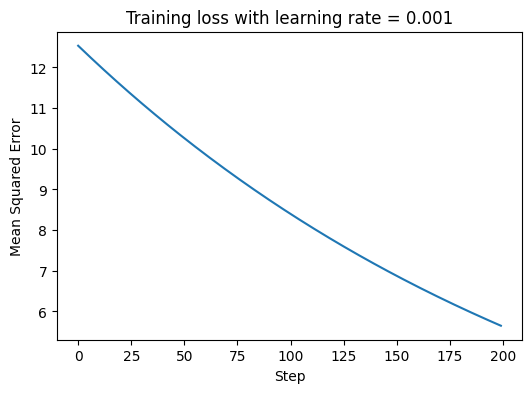

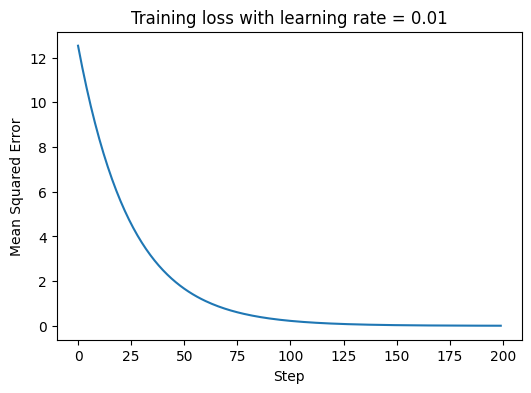

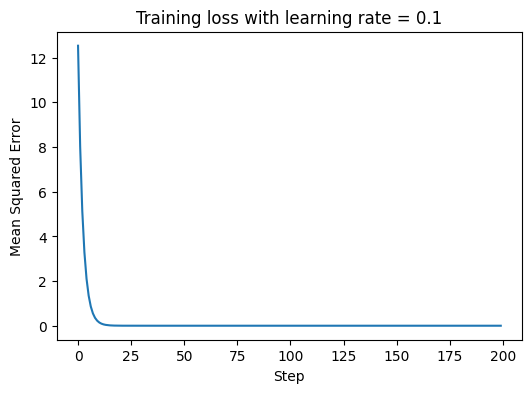

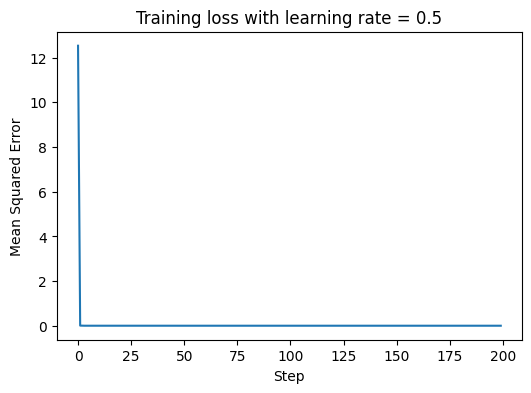

In [33]:
# Section 11 - Compare different learning rates

learning_rates = [0.001, 0.01, 0.1, 0.5]
histories = {}

for lr in learning_rates:
    _, _, hist = train_linear_regression(X, y, learning_rate=lr, n_steps=200)
    histories[lr] = hist

for lr in learning_rates:
    plt.figure(figsize=(6, 4))
    plt.plot(histories[lr])
    plt.xlabel("Step")
    plt.ylabel("Mean Squared Error")
    plt.title(f"Training loss with learning rate = {lr}")
    plt.show()



The learning rate strongly affects the speed of convergence.  
A very small learning rate decreases the loss slowly, while larger learning rates reach the plateau much faster.

In this example, the larger tested learning rates remain stable, but in general an excessively large learning rate can make training unstable.


### Exercises for Section 11

**Exercise 11.1**  
Compare the loss curves for multiple learning rates.

**Exercise 11.2**  
Decide which learning rates:
- converge slowly
- converge well
- are unstable

**Exercise 11.3**  
Why can a large learning rate be problematic?


In [34]:
# Exercises for Section 11

# Write your code below.


## Section 12 — Biological interpretation of the fitted model

The model coefficients tell us how each standardized feature contributes to the predicted number of detected genes.

A positive coefficient means:

- increasing that feature tends to increase the predicted quality score

A negative coefficient means:

- increasing that feature tends to decrease the predicted quality score


In [35]:
# Section 12 - Inspect the fitted coefficients

for name, coef in zip(feature_names, w_fit):
    print(f"{name}: {coef:.4f}")


log10_total_counts: 0.1779
pct_mito: -0.0236


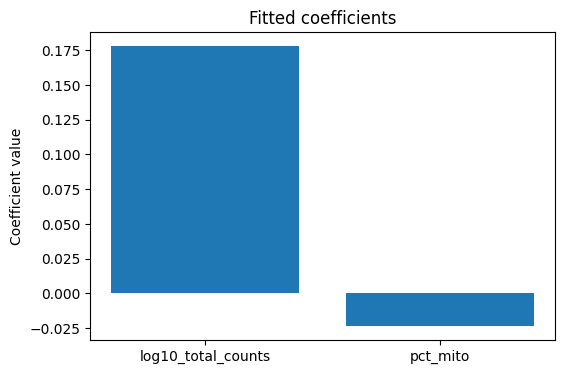

In [36]:
# Section 12 - Plot the fitted coefficients

plt.figure(figsize=(6, 4))
plt.bar(feature_names, w_fit)
plt.ylabel("Coefficient value")
plt.title("Fitted coefficients")
plt.show()



The coefficient for `log10_total_counts` is positive and larger in magnitude, suggesting that total counts are strongly associated with the number of detected genes.

The coefficient for `pct_mito` is slightly negative, suggesting that higher mitochondrial percentage is associated with a small decrease in the predicted number of detected genes, after standardization.


### Questions for interpretation

1. Which feature has a positive association with the target?
2. Which feature has a negative association with the target?
3. Does the model seem biologically reasonable?
4. Which feature appears most strongly associated with the number of detected genes?


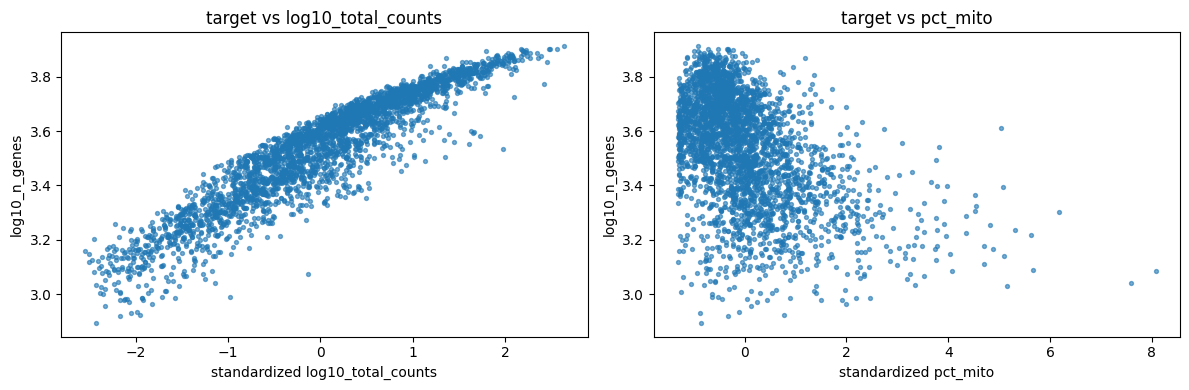

In [37]:
# Section 12 - Optional extra visualization
# We compare the target to each feature again, now keeping in mind the fitted coefficients.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X[:, 0], y, s=8, alpha=0.6)
axes[0].set_xlabel("standardized log10_total_counts")
axes[0].set_ylabel("log10_n_genes")
axes[0].set_title("target vs log10_total_counts")

axes[1].scatter(X[:, 1], y, s=8, alpha=0.6)
axes[1].set_xlabel("standardized pct_mito")
axes[1].set_ylabel("log10_n_genes")
axes[1].set_title("target vs pct_mito")

plt.tight_layout()
plt.show()



The final scatter plots are consistent with the fitted coefficients.  
`log10_total_counts` has a clear positive association with the target, while `pct_mito` shows a weaker and more diffuse negative relationship.

This supports the interpretation that total counts are the dominant predictor in this simple model.


## Section 13 — Final recap

In this notebook we:

- imported a real single-cell RNA sequencing dataset exported from Bioconductor and specifically processed for LR
- represented a biological dataset as a matrix in NumPy
- clarified the difference between matrix orientation in bioinformatics and machine learning
- performed basic NumPy operations on real biological data
- defined a linear regression model
- computed predictions, residuals, and the Mean Squared Error
- understood the gradient as the direction of steepest increase
- implemented Gradient Descent
- evaluated the model visually and numerically
- interpreted the fitted coefficients in a biological context

### Final reflection questions

1. Why do we usually want a matrix with rows as cells and columns as features in machine learning?
2. What is the role of the Mean Squared Error in this lab?
3. Why does the gradient help us optimize the model parameters?
4. Why can feature scaling improve Gradient Descent?
5. Which plots did you find most useful for understanding the model?


In [38]:
# Final notes
# You can use this final code cell for personal notes,
# further experiments, or additional plots.
